# Customer Churn Prediction 

### 1. Introduction

Customer churm refers to customers discontinuing a company's services. In the telecom industry, high churn leads to significant revenue loss and increased customer acquisition consts.

This project builds a supervised binary classification model to predict customer churn using demographic, account, and service-related features to support proactive retention strategies.
        


### 2. Problem Statement

Telecom companies face significant revenue loss due to customer churn, as customers frequently switch to competitors because of pricing, service quality, or contract flexiblity. Identifying cutomers who are likely to discontinue thier service is challenging without data-driven insights. Therfore, there is a need for a predictive system that can identify high-risk customers before they leave.

### 3. Business Objective

The primary business objective is to identify high-risk customers in advance so that the company can implement targeted retention strategies and reduce revenue loss.

This enables the organization to:
* Reduce revenue loss
* Increase customer lifetime value
* Lower customer acquisition costs
* Improve overall profitability
 
The predictive model serves as a decision-support tool to help business stakeholders make data-driven retention decisions.

### 4. Dataset Overview

The Dataset used is the Telco Customer Churn dataset containing 7,043 customer records and 21 features. It includes demographic details, account informatio, and service usage data.

Key Feature Categories:

* Demographics (Gender, SeniorCitizen, Partner, Dependents)
* Account Information (Tenure, Contract, PaymentMethod, MonthlyCharges, TotalCharges)
* Services (InternetService, Techsupport, StreamingTV, etc)

The target variable is churn, Indicating whether a customer has left (Yes) or stayed (No).

The dataset contains both categorical and numerical features, requring preprocessing before model traning.

### 5. EDA

In [3]:
# All important libraries

# Data Handling
import numpy as np
import pandas as pd

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline
# Models

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report,
    roc_auc_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE 
from sklearn.model_selection import GridSearchCV

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")
 


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
df = pd.read_csv('Telco_Customer_Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
#Drop cutomer id becasue it is just a identifier with no predictive values
df = df.drop(columns= ['customerID']) 
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Converting blank spaces of Totalchargers col in 0.01 and making sure its a float.
df['TotalCharges'] = df['TotalCharges'].replace({" ": "0.0"}).astype(float)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# checking data is balanced on not.
df["Churn"].value_counts()
print(f"Class Imbalanced ratio : {df['Churn'].value_counts()[0] / df['Churn'].value_counts()[1]:.2f}:1")
#If we train directly so our model will be biased towards predicting no churn and thats why using this mod for fixing this imbalanced.

Class Imbalanced ratio : 2.77:1


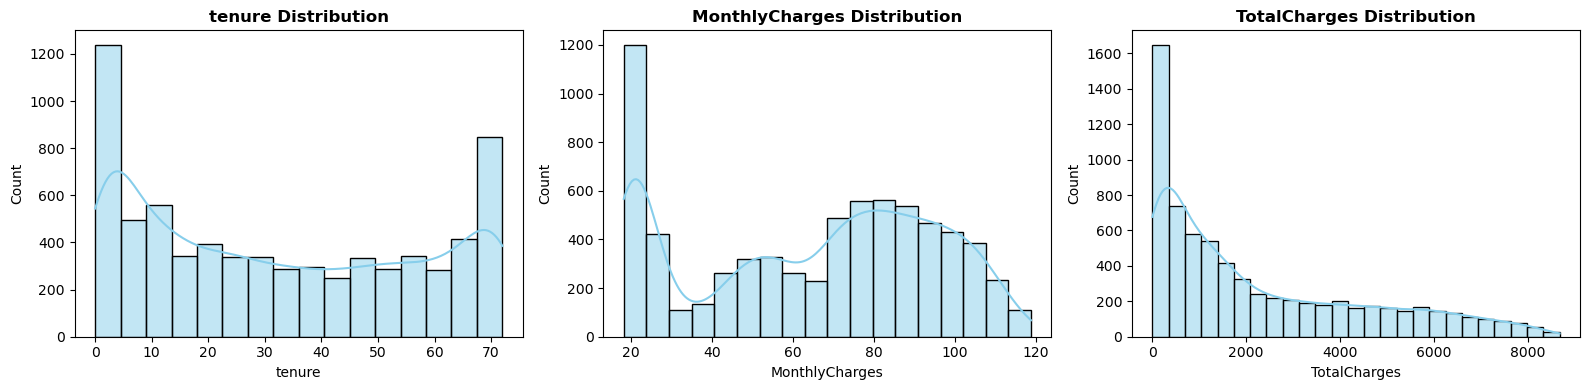

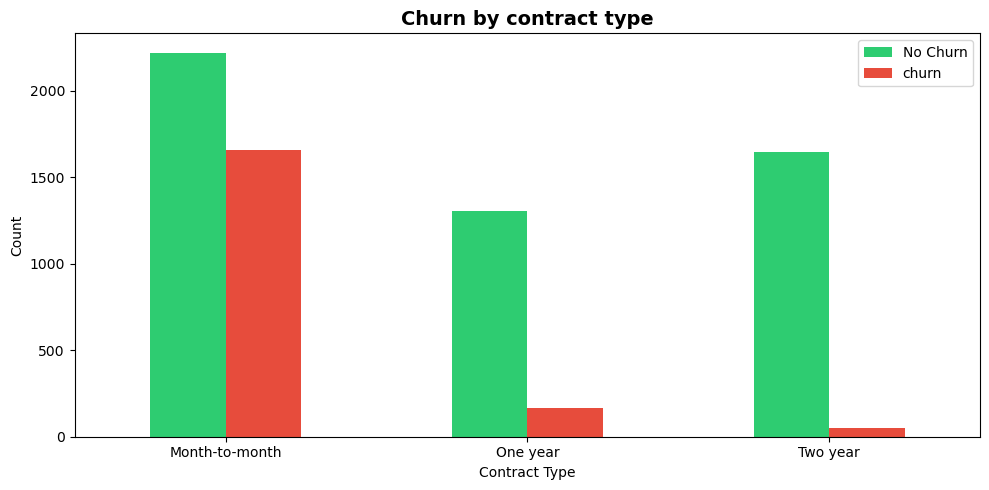

In [ ]:
# Key pattern visualization
fig , axes = plt.subplots(1,3, figsize = (16,4))

for idx, col in enumerate(["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(df[col], kde= True, ax= axes[idx], color = 'skyblue')
    axes[idx].set_title(f'{col} Distribution', fontsize = 12, fontweight = 'bold')

plt.tight_layout()
plt.show()

#Churn by contract
fig, ax = plt.subplots(1,1, figsize = (10, 5))
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack(fill_value = 0)
contract_churn.plot(kind = 'bar', stacked = False, ax= ax, color = ['#2ecc71', "#e74c3c"])
ax.set_title('Churn by contract type', fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Count')
ax.legend(['No Churn', 'churn'])
ax.set_xticklabels(ax.get_xticklabels(), rotation = 0)
plt.tight_layout()
plt.show()

### 6.Model Building

In [ ]:
X = df.drop('Churn', axis = 1)
Y = df['Churn'].map({'Yes':1, 'No': 0})

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size = 0.2,
                                                    stratify=Y, 
                                                    random_state=42
                                                    )

x_train.shape[0]
# Both sets have same churn ratio.

5634

In [ ]:
y_test.shape[0]

1409

In [ ]:
x_train.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [ ]:
# Encoding
# Encode binary columns by Converting all text features to numbers.
categorical_cols = x_train.select_dtypes(include = 'object').columns
numerical_cols = x_train.select_dtypes(exclude = 'object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)
# Instead of manual encoding i have used OneHotEncoder makes it automatic endoding.

In [ ]:
#Building pipeine
pipeline = Pipeline(steps = [
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state= 42)),
    # Trainig of the model using XGboost algorithm
    #XG boost - > It is the gradient decent algorithms which basically builds multiple decision tree sequencially where each tree tries to find the errors of the previous trees.
    ('model', XGBClassifier(
        n_estimators = 200, 
        max_depth = 5, 
        learning_rate = 0.1,
        random_state = 42,
        eval_metric = 'logloss'
        
    ))
    
])

In [ ]:
# Hyperparameter Tuning
param_grid ={
    'model__n_estimators': [100,200],
    'model__max_depth': [4,6],
    'model__learning_rate' : [0.05,0.1]
}

grid_search = GridSearchCV(
    estimator = pipeline,
    param_grid=param_grid,
    cv = 5,
    scoring ='roc_auc',
    n_jobs = -1
    )

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 100}


In [ ]:
# To show the visual workflow diagram format.
from sklearn import set_config
set_config(display='diagram')

best_model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtec...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:,-1]


In [ ]:
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test,y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report,(y_test,y_test_pred))


Train Accuracy: 0.7997870074547391
Test Accuracy: 0.7693399574166075
F1 Score: 0.6198830409356725
ROC AUC: 0.8437921413624739
<function classification_report at 0x0000015A67FD0900> (437     0
2280    0
2235    0
4460    0
3761    0
       ..
5143    0
4439    0
3857    0
4758    0
5613    0
Name: Churn, Length: 1409, dtype: int64, array([0, 1, 0, ..., 0, 0, 0]))


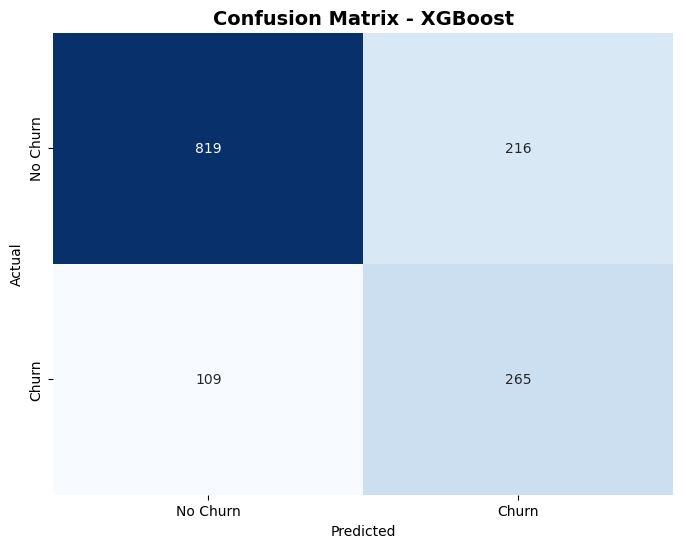

In [ ]:
# lets visualize that prediction with confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize = (8,6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = False, xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])

plt.title('Confusion Matrix - XGBoost', fontsize = 14, fontweight = 'bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

So this confusion matrix shows that -> <br>
- 1.Top Left is the True Negative -> It means customers we correctly predict would stay.
- 2.Bottom Right is True Positive -> It means that customers we correctly predicted would churn.
- 3.Top Right is False Positive -> It means how much we predicted churned but they stayed. Like we predicted that they will leave but they actually stayed.
- 4.Bottom Left is Flase negative -> It means that we predicted that they will stay but they churn.

In [ ]:
# Feature Importance like XG boost can tell exactly that which features matters most.

preprocessor = best_model.named_steps['preprocessing'] #get the preprocessor

feature_names = preprocessor.get_feature_names_out() #get features name after encoding

feature_names = [name.split('__')[-1] for name in feature_names] # for removing cat__ from the names

xgb_model = best_model.named_steps['model']
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending= False)



feature_importance.head(10)



,Feature,Importance
36,Contract_Month-to-month,0.278924
18,OnlineSecurity_No,0.079307
16,InternetService_Fiber optic,0.062542
27,TechSupport_No,0.056534
20,OnlineSecurity_Yes,0.040889
39,PaperlessBilling_No,0.037489
35,StreamingMovies_Yes,0.034941
43,PaymentMethod_Electronic check,0.034025
40,PaperlessBilling_Yes,0.032074
8,Dependents_No,0.030646


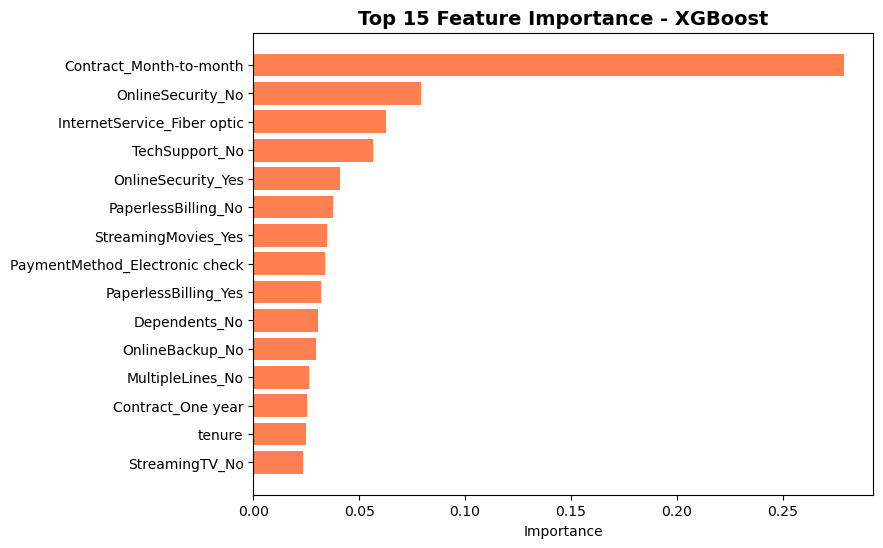

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15], color = 'coral')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance - XGBoost', fontsize = 14, fontweight = 'bold')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Cross validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(pipeline, X, Y, cv = 5, scoring='roc_auc')
print("Cross Validation ROC-AUC:", cv_scores.mean())

Cross Validation ROC-AUC: 0.8338654530481262


In [4]:
# SHAP explanation used to interprit how ML models make thier predictions. Its a powerfull and theoratically sound method in explainable AI
import shap 
xgb_model = best_model.named_steps['model']
x_train_transformed = best_model.named_steps['preprocessing'.transform(x_train)]

#create shap explaner
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(x_train_transformed)

shap.summary_plot(shap_values, x_train_transformed)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
# # Saving the model as well as pipeline
joblib.dump(xgb_model,'customer_churn_model.pkl')
joblib.dump(pipeline,'customer_churn_pipeline.pkl')

['customer_churn_pipeline.pkl']